<a href="https://colab.research.google.com/github/msbeigi/competition-house-prices/blob/main/Kaggle_House_Prices_Advanced_Regression_Techniques_with_columnsTransformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo pip install xgboost
!pip install catboost


In [37]:
import numpy as np
import pandas as pd
from IPython.display import display,HTML
from pandas.core.dtypes.missing import isna
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
# import seaborn as sns
import xgboost

from pandas.core.series import Series
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, DotProduct
from sklearn.linear_model import Lasso, ElasticNet,LinearRegression,Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
# from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import datetime
import xgboost
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import StackingRegressor
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

import seaborn as sns
import matplotlib.pyplot as plt


In [38]:

path_train='/content/drive/MyDrive/ML/Hand-on/House pricing - kaggle/train.csv'
path_test='/content/drive/MyDrive/ML/Hand-on/House pricing - kaggle/test.csv'



In [39]:

df_train=pd.read_csv(path_train)
df_test=pd.read_csv(path_test)


In [40]:

def get_categorical_cols(df):
    all_cols=df.columns
    num_cols=df._get_numeric_data().columns
    cat_cols=list(set(all_cols)-set(num_cols))
    return (cat_cols)

def data_prepration(df,istrain=True):
    cat_list=get_categorical_cols(df)
    for col in cat_list:
      df[col].fillna( 'NA',inplace=True)


    df['MasVnrType'].fillna('No',inplace=True)
    df['MasVnrArea'].fillna(0,inplace=True)
    df['FireplaceQu'].fillna('No',inplace=True)
    df['LotFrontage'].fillna(0,inplace=True)
    # df['GrageCond'].fillna('No',inplace=True)
    df['BsmtExposure'].fillna('No',inplace=True)
    df['BsmtQual'].fillna('No',inplace=True)
    df['BsmtCond'].fillna('No',inplace=True)
    df['BsmtFinType1'].fillna('Unf',inplace=True)

    # df['BsmtFinType2'].fillna('Unf',inplace=True)
    df['BsmtFinType1'].fillna('SBrkr',inplace=True)

    return df

def eng_feature(df, istrain=True):
  df[['BsmtUnfSF','BsmtFinSF1','BsmtFinSF2']] = df[['BsmtUnfSF','BsmtFinSF1','BsmtFinSF2']].fillna(0)

  # Total Square Footage
  df['TotalSF'] = (df['BsmtFinSF2'].fillna(0) + df['BsmtFinSF1'].fillna(0) + df['1stFlrSF'].fillna(0) + df['2ndFlrSF'].fillna(0))
  df['TotalArea'] = (df['TotalBsmtSF'].fillna(0) + df['GrLivArea'].fillna(0) )

  # Age of the House
  df['HouseAge'] = df['YrSold'] - df['YearBuilt'].fillna(0)

  # Total Bathrooms
  df['TotalBathrooms'] = (df['FullBath'].fillna(0)  + df['BsmtFullBath'].fillna(0) + 0.5*(df['BsmtHalfBath'].fillna(0)+ df['HalfBath'].fillna(0)))

  # Overall Quality and Condition Interaction
  # df['OverallQualCond'] = (df['OverallQual'].fillna(0) * df['OverallCond'].fillna(0))

  # Interaction Between Living Area and Quality
  # df['GrLivAreaQual'] = (df['GrLivArea'].fillna(0) * df['OverallQual'].fillna(0))


  # Interaction Between Garage Cars and Area
  df['GarageCarsArea'] = (df['GarageCars'].fillna(0) * df['GarageArea'].fillna(0))

  # Age of the Remodeled Part of the House
  df['RemodeledAge'] = (df['YrSold']  - df['YearRemodAdd'].fillna(0))

  # Total Porch Area
  df['TotalPorchArea'] = (df['OpenPorchSF'].fillna(0) + df['EnclosedPorch'].fillna(0) + df['3SsnPorch'].fillna(0) + df['ScreenPorch'].fillna(0)+df['WoodDeckSF'].fillna(0))

  # Has Pool, Fence, and Other Features
  # df['HasPool'] = df['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
  # df['HasFence'] = df['Fence_encoded'].apply(lambda x: 0 if pd.isnull(x) else 1)
  # df['HasMiscFeature'] = df['MiscFeature_encoded'].apply(lambda x: 0 if pd.isnull(x) else 1)

  # season
  season_mapping = {1: 1, 2: 1, 3: 2, 4: 2, 5: 2, 6: 3, 7: 3, 8: 3, 9: 4, 10: 4, 11: 1, 12: 1}
  df['SeasonSold'] = df['MoSold'].map(season_mapping)

  df['LotArea_log'] = np.log1p(df['LotArea'])
  df['TotalSF_log'] = np.log1p(df['TotalSF'])
  neighborhood_to_mean={}
  if(istrain):
    neighborhood_mean = df.groupby('Neighborhood')['SalePrice'].mean()

    # Divide each mean by 1,000 and round to get a simplified value
    neighborhood_mean_divided = round(neighborhood_mean / 1000, 0)

    # Create a mapping dictionary from 'Neighborhood' to 'neighborhood_mean_divided'
    neighborhood_to_mean = neighborhood_mean_divided.to_dict()

    # Add the mean sale price as a new feature to df_train
    # df['MeanSalePrice_by_Neighborhood'] = df['Neighborhood'].map(neighborhood_to_mean)

  drop_col=['MoSold','YearRemodAdd','GarageArea'#,'OverallQual','GrLivArea','OverallCond'
            ,'FullBath','HalfBath','OpenPorchSF',
            'EnclosedPorch','3SsnPorch','ScreenPorch','BsmtFullBath','BsmtHalfBath','YearBuilt','TotalBsmtSF','1stFlrSF','2ndFlrSF','PoolArea',
            'Alley','GarageYrBlt','BsmtFinSF1', 'BsmtFinSF2','BsmtUnfSF'
            # 'Fence_encoded','MiscFeature_encoded',
            ,'BsmtCond','PoolQC', 'MiscFeature', 'Fence', 'GarageCond', 'BsmtFinType2'#,'FireplaceQu'
            ,'WoodDeckSF','YrSold','LotArea']

  if(istrain):
    df['SalePrice_']=np.log1p(df['SalePrice'])
    # drop_col=drop_col+['Neighborhood']#,'SalePrice']


  df.drop(drop_col,axis=1,inplace=True)


  return df,neighborhood_to_mean

### EDA

<ipython-input-41-b4f8dad5579f>:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
<ipython-input-41-b4f8dad5579f>:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
<ipython-input-41-b4f8dad5579f>:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
<ipython-input-41-b4f8dad5579f>:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
<ipython-input-41-b4f8dad5579f>:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
<ipython-input-41-b4f8dad5579f>:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax

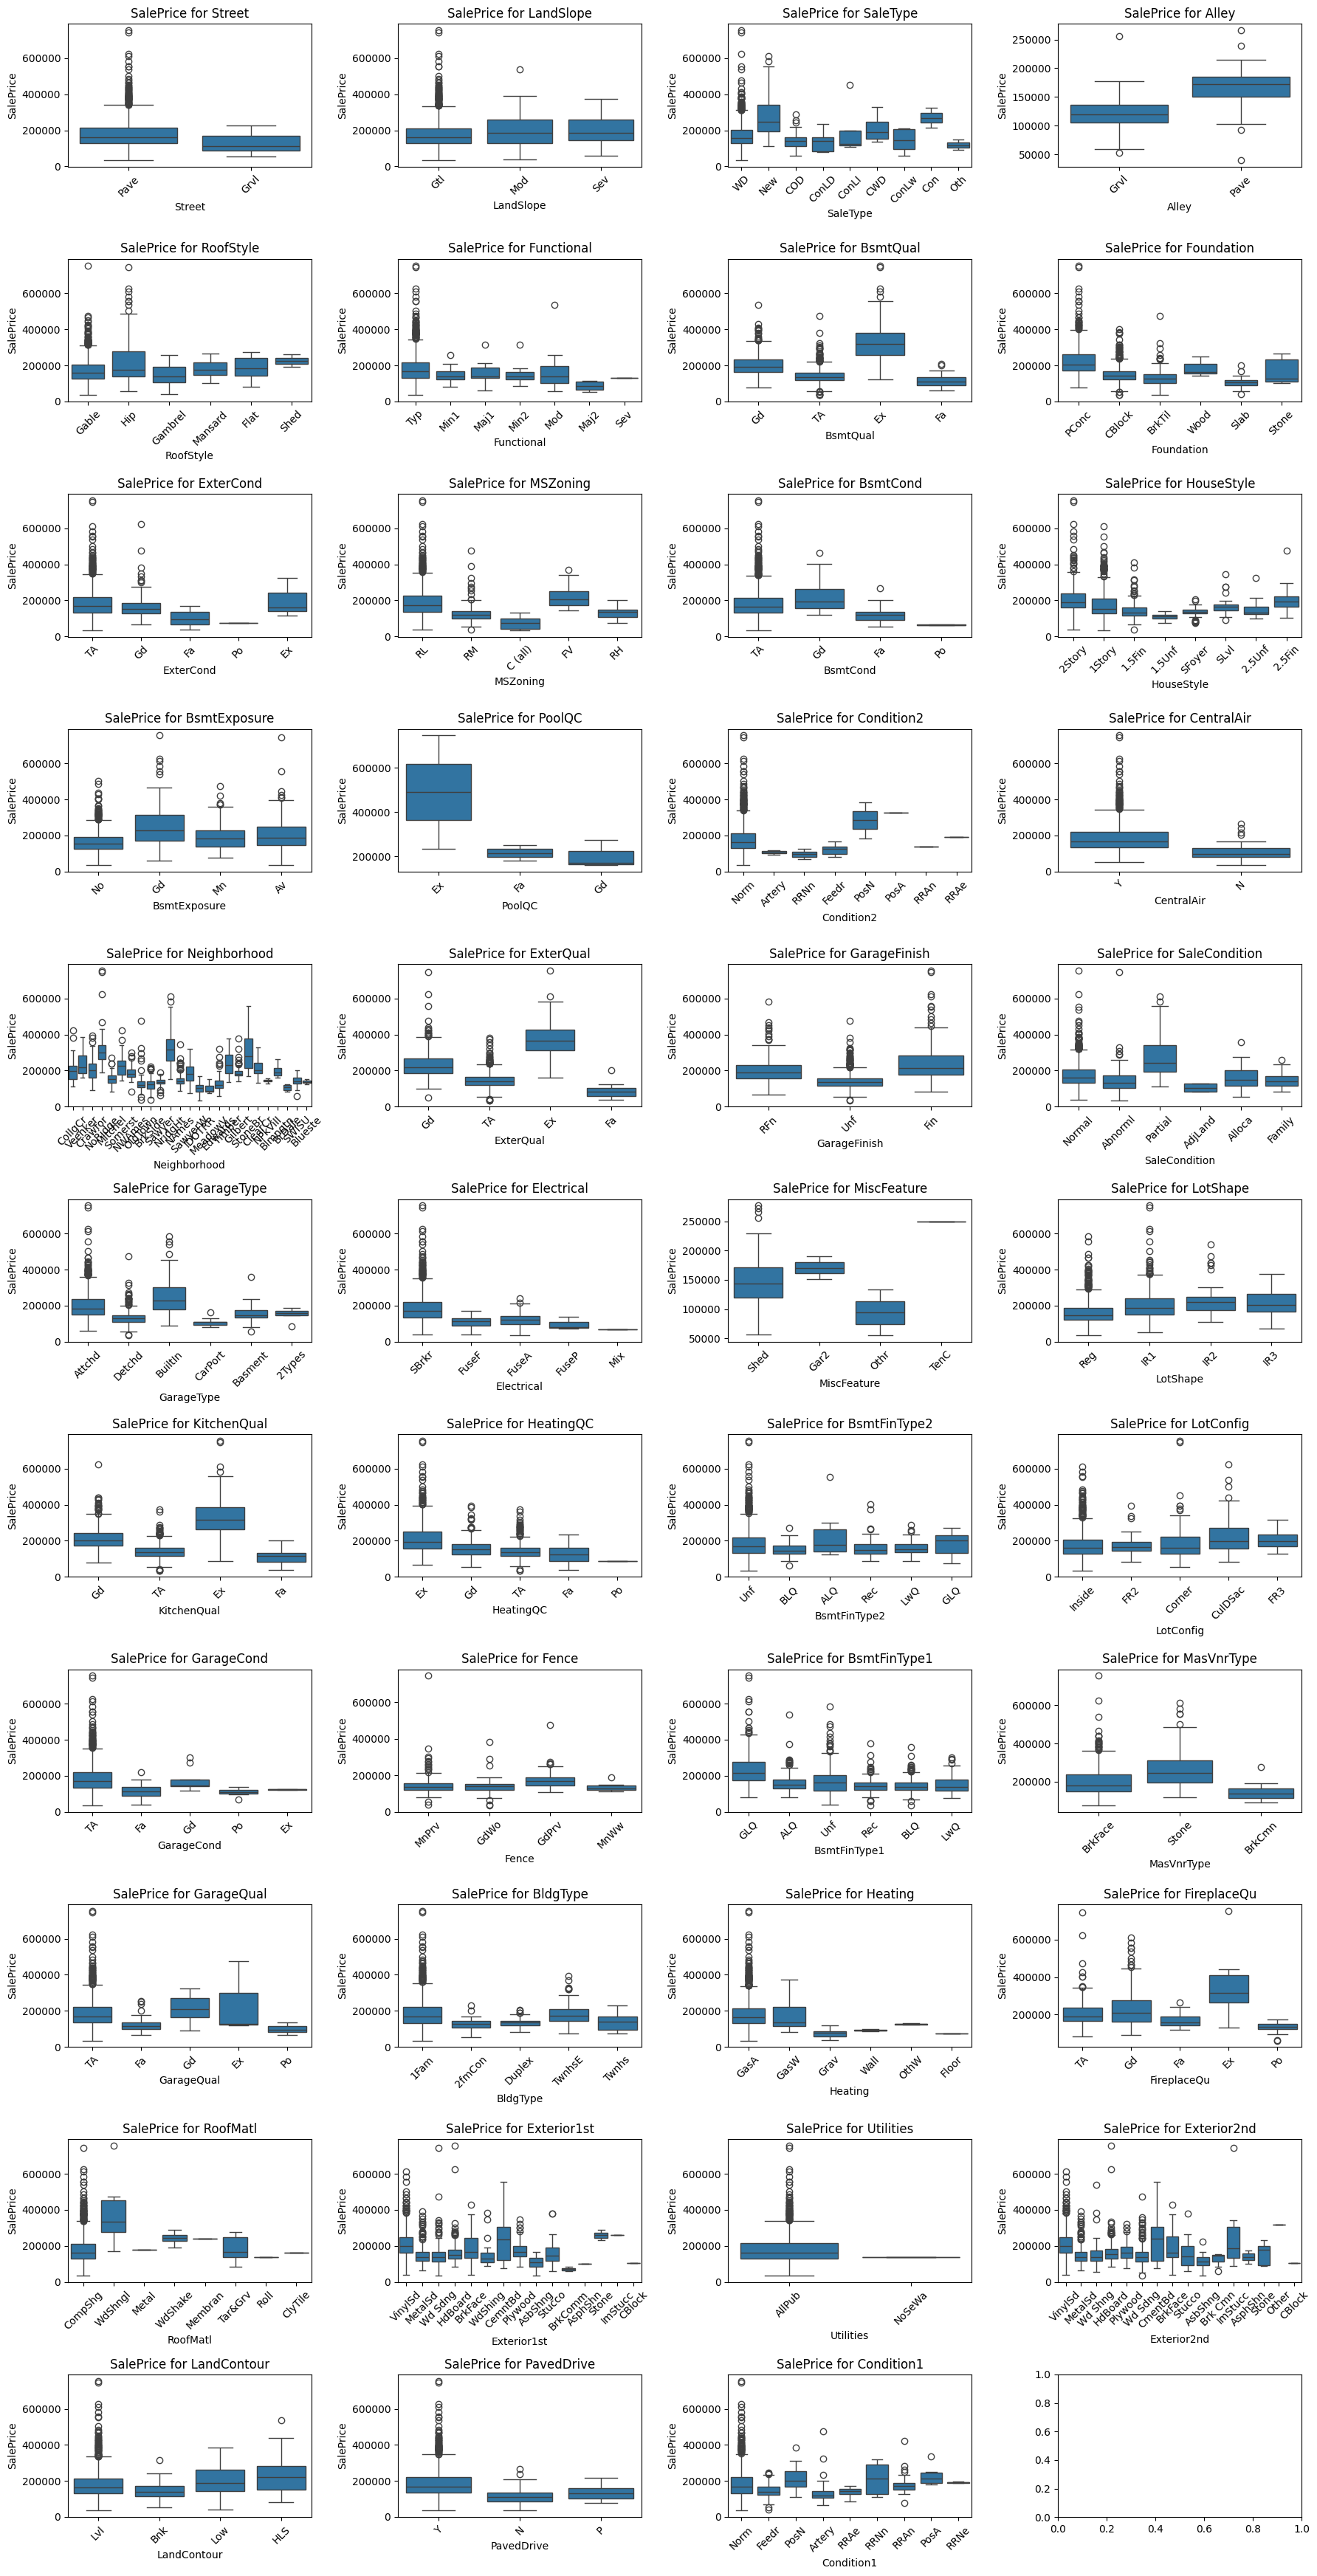

In [41]:
fig, axes = plt.subplots(nrows=11, ncols=4, figsize=(18, 35))
axes = axes.flatten()
plt.subplots_adjust(wspace=1.5, hspace=0.8)
cat_list=get_categorical_cols(df_train)


for i, feature in enumerate(cat_list):

    sns.boxplot(x=feature, y='SalePrice', data=df_train,ax=axes[i])
    axes[i].set_title(f'SalePrice for {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()


In [42]:
df_train_=data_prepration(df_train.copy(),istrain=True)
df_train_,_=eng_feature(df_train_, istrain=True)

In [43]:
df_test_=data_prepration(df_test.copy(),istrain=True)
df_t_,_=eng_feature(df_test_,istrain=False)
df_t_.drop('Id',axis=1,inplace=True)


In [44]:
outlier_ids=[598, 955, 935, 1299, 250, 314, 336, 707, 1183, 692, 186, 441, 186, 524, 739, 955, 636, 1062, 1191, 496, 198]
df_no_oulier=df_train_[df_train_.Id.isin(outlier_ids)==False]

In [45]:
order = ['LotShape','LandContour','Utilities','BsmtQual','BsmtFinType1','CentralAir','Functional','FireplaceQu','GarageFinish','GarageQual','PavedDrive','ExterCond','OverallQual','KitchenQual'
,'LandSlope', 'ExterQual', 'HeatingQC','BsmtExposure']
onehot=['Street','LotConfig','Neighborhood', 'Condition1','Condition2','BldgType','HouseStyle','RoofStyle','Exterior1st','Exterior2nd','MasVnrType','Electrical','Foundation','SaleType','MSZoning',
        'SaleCondition','Heating','GarageType','RoofMatl']

num_cols = [col for col in df_train._get_numeric_data().columns if col not in ['Id', 'SalePrice','1stFlrSF','GarageArea','MoSold','PoolArea','OpenPorchSF','EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'WoodDeckSF','2ndFlrSF','GarageYrBlt','BsmtFullBath','BsmtHalfBath', 'FullBath', 'HalfBath', 'YrSold','LotArea','YearBuilt','YearRemodAdd','BsmtFinSF1','TotalBsmtSF','BsmtFinSF2','BsmtUnfSF']]
print(num_cols)


num_pip=Pipeline(steps=(
    [('impute',SimpleImputer(strategy='mean')),
     ('scalr',StandardScaler())]))

ord_pip=Pipeline(steps=[
                ('impute',SimpleImputer(strategy='most_frequent')),
                  ('ode',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))])

onehot_pip=Pipeline(steps=[
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False)),
    ])

col_trans=ColumnTransformer(transformers=[
    ('num',num_pip,num_cols),
    ('onehot',onehot_pip,onehot),
    ('ord',ord_pip,order)],
      remainder='passthrough',
      n_jobs=-1)

['MSSubClass', 'LotFrontage', 'OverallQual', 'OverallCond', 'MasVnrArea', 'LowQualFinSF', 'GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'MiscVal']


In [46]:
pip=Pipeline(steps=[('preprocessing',col_trans)])
X=df_no_oulier.drop(['SalePrice_','SalePrice','Id'],axis=1)
y=df_no_oulier['SalePrice_']

In [47]:
X_preprocessed=pip.fit_transform(X)
X_preprocessed_test=pip.transform(df_t_)

/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


In [48]:
X_train,X_test,y_train,y_test=train_test_split(X_preprocessed, y, test_size=0.3, random_state=42)


## RandomForest

In [49]:
rf=RandomForestRegressor(max_depth= 20, max_features= 'sqrt', min_samples_leaf= 1, min_samples_split= 2, n_estimators= 1000)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
print(np.sqrt(mean_squared_error(y_test,y_pred_rf)))
#

0.13110268787787238


In [50]:
y_pred_test=rf.predict(X_preprocessed_test)
y_pred_df = pd.DataFrame(np.expm1(y_pred_test), index=df_submission_sample.index, columns=['Predicted_SalePrice'])

pd.DataFrame(zip(y_pred_df['Predicted_SalePrice'],df_submission_sample['SalePrice']),columns=['prediction','true'])


,prediction,true
0,122845.785074,169277.052498
1,156473.881561,187758.393989
2,183412.186281,183583.683570
3,191088.921955,179317.477511
4,191095.590602,150730.079977
...,...,...
1454,87971.897695,167081.220949
1455,96126.748828,164788.778231
1456,160512.848581,219222.423400
1457,112326.850342,184924.279659


## Cat Boost

In [51]:
cat= CatBoostRegressor(iterations=3000,
    learning_rate=0.008,
    depth=6,
    l2_leaf_reg=4,
    random_strength=5,
    bagging_temperature=0.1,
    border_count=512,
    eval_metric='RMSE',verbose=0)
cat.fit(X_train,y_train)
y_pred_cat=cat.predict(X_test)
print(np.sqrt(mean_squared_error(y_test,y_pred_cat)))
pd.DataFrame(zip(y_test,y_pred_cat),columns=['true','prediction'])

0.11467834939156285


,true,prediction
0,12.119975,12.203664
1,12.220966,12.296324
2,11.589896,11.644217
3,12.666660,12.635328
4,12.485831,12.507020
...,...,...
428,12.128117,11.991424
429,12.577640,12.631751
430,12.254868,12.291352
431,12.127576,12.130389


In [52]:

y_pred_original = np.expm1(y_pred_cat)
# y_pred_original

In [53]:
y_sale=pd.concat([ df_no_oulier,y_test],join='inner',axis=1)
y_pred_cat_df = pd.DataFrame(y_pred_cat, index=y_test.index, columns=['Predicted_SalePrice'])
y_sale = pd.concat([y_sale, y_pred_cat_df], axis=1)
y_sale['Pred_SalePrice']=np.expm1(y_sale['Predicted_SalePrice'])
y_sale[['Pred_SalePrice','SalePrice']]


,Pred_SalePrice,SalePrice
10,126354.165805,129500
15,128741.489879,132000
23,135612.062438,129900
29,74496.140683,68500
30,89808.280363,40000
...,...,...
1448,105279.029360,112000
1449,93353.090091,92000
1450,131220.176685,136000
1452,129389.703651,145000


## GradientBoosting

In [54]:
GBoost =GradientBoostingRegressor(n_estimators=3000, learning_rate=0.0098,
                                   max_depth=4, max_features='sqrt',
                                   min_samples_leaf=15, min_samples_split=4,
                                   loss='huber', random_state =5)
GBoost.fit(X_train,y_train)
y_pred_gb=GBoost.predict(X_test)

print((mean_squared_error(y_test,y_pred_gb)))

0.012685981737856499


In [55]:
y_sale_gb=pd.concat([ df_no_oulier,y_test],join='inner',axis=1)
y_pred_gb_df = pd.DataFrame(y_pred_gb, index=y_test.index, columns=['Predicted_SalePrice'])
y_sale_gb = pd.concat([y_sale_gb, y_pred_gb_df], axis=1)
y_sale_gb['Pred_SalePrice']=np.expm1(y_sale_gb['Predicted_SalePrice'])
y_sale_gb[['Pred_SalePrice','SalePrice']]


,Pred_SalePrice,SalePrice
10,127491.607398,129500
15,135552.222814,132000
23,141601.488249,129900
29,70560.501606,68500
30,95616.527359,40000
...,...,...
1448,109610.647805,112000
1449,87088.885861,92000
1450,129089.925974,136000
1452,134016.748168,145000


## Test dataset

In [57]:
y_gb_pred_test=GBoost.predict(X_preprocessed_test)

df_res=df_test[['Id']]
df_res['SalePrice']=y_gb_pred_test

df_res['SalePrice']=round(np.expm1(df_res['SalePrice']), 4)

df_res.to_csv('/content/drive/MyDrive/ML/Hand-on/House pricing - kaggle/gb_result.csv',index=False)
df_res


<ipython-input-57-2bcd3af4b428>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['SalePrice']=y_gb_pred_test
<ipython-input-57-2bcd3af4b428>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['SalePrice']=round(np.expm1(df_res['SalePrice']), 4)


,Id,SalePrice
0,1461,122379.8791
1,1462,165961.3713
2,1463,187733.8308
3,1464,198772.1364
4,1465,185974.2171
...,...,...
1454,2915,78984.5958
1455,2916,88051.6216
1456,2917,175549.8479
1457,2918,109701.9825
